# Supermart Grocery Sales - Retail Analytics & Machine Learning Project

# Problem Statement

Supermarket businesses generate large volumes of sales data that contain valuable insights into customer purchasing behavior, product performance, and revenue trends. Analyzing this data can help identify key factors influencing sales and support data-driven business decisions. This project aims to perform exploratory data analysis and develop machine learning models to predict sales outcomes using historical supermarket transaction data.

# Tools Used

## Python

## Pandas

## NumPy

## Matplotlib

## Seaborn

## Scikit-learn

ML Models :
- Linear Regression
- Random Forest Regressor
- LabelEncoder
- StandardScaler
- train_test_split
- Mean Squared Error (MSE)
- R² Score



## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


## Load Dataset

In [ ]:
df = pd.read_csv('/content/Supermart Grocery Sales - Retail Analytics Dataset.csv')
df.head()

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu


## Data Cleaning & Feature Engineering

In [ ]:
df.drop_duplicates(inplace=True)

df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    format='%d-%m-%Y',
    errors='coerce'
)

df['month_no'] = df['Order Date'].dt.month
df['Month'] = df['Order Date'].dt.month_name()
df['year'] = df['Order Date'].dt.year


## Sales by Category

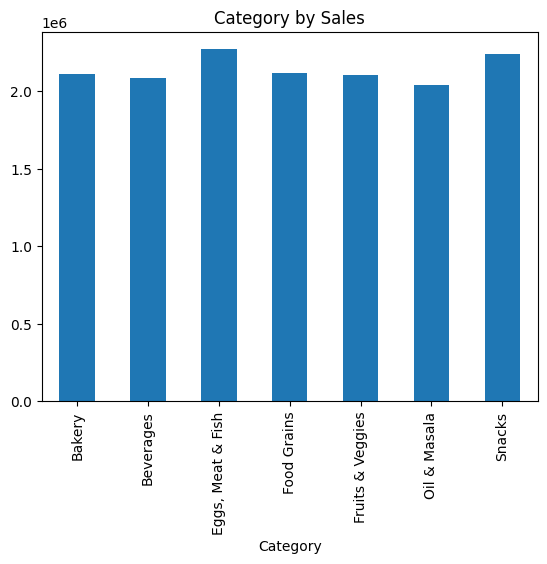

In [ ]:
sales_category = df.groupby('Category')['Sales'].sum()
sales_category.plot(kind='bar')
plt.title('Category by Sales')
plt.show()

### Interpretation

The category-wise sales analysis reveals that certain product categories contribute significantly more revenue than others. The highest-performing category generates the largest share of total sales, indicating strong customer demand within that segment. Categories with consistently high sales should receive priority in inventory planning, promotional campaigns, and supplier management to maximize revenue growth.

### Business Insight

Focusing on top-selling categories can improve profitability and customer satisfaction by ensuring product availability and optimizing marketing investments.


## Sales by Month

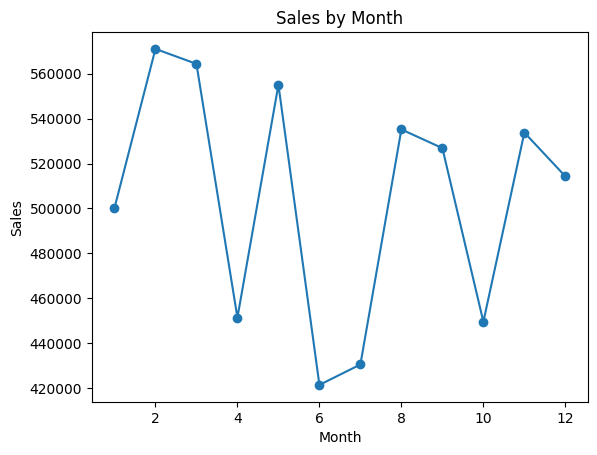

In [ ]:
monthly_sales = df.groupby('month_no')['Sales'].sum()

monthly_sales.plot(marker='o')
plt.title('Sales by Month')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

### Interpretation

The monthly sales trend highlights fluctuations in customer purchasing behavior throughout the year. Certain months experience higher sales volumes, indicating seasonal demand patterns and increased customer activity. Understanding these trends helps identify peak sales periods and supports more accurate demand forecasting.

### Business Insight

The company can use these insights to plan inventory levels, promotional campaigns, and staffing requirements during high-demand months to maximize sales opportunities.


## Sales by Year

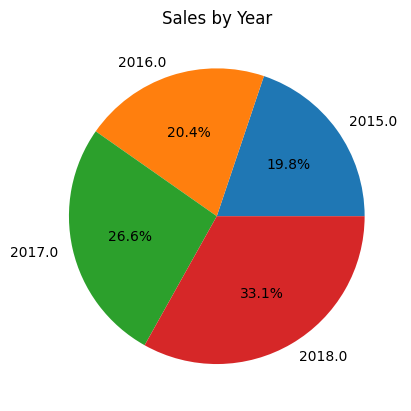

In [ ]:
yearly_sales = df.groupby('year')['Sales'].sum()

plt.pie(yearly_sales, labels=yearly_sales.index, autopct='%1.1f%%')
plt.title('Sales by Year')
plt.show()

### Interpretation

The yearly sales distribution shows how business performance has evolved over time. The years with the largest share of total sales indicate periods of strong business growth and increased customer engagement. The upward trend suggests that the company has successfully expanded its customer base and revenue generation capabilities.

### Business Insight

Monitoring yearly sales growth helps management evaluate business performance and develop long-term strategies for sustainable expansion.


## Top 5 Cities by Sales

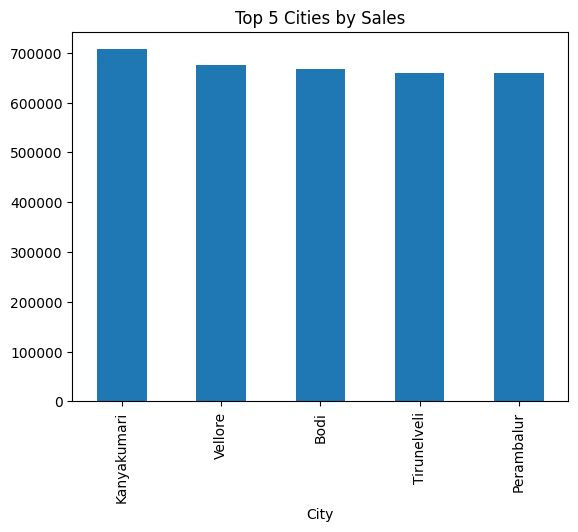

In [ ]:
top_cities = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(5)

top_cities.plot(kind='bar')
plt.title('Top 5 Cities by Sales')
plt.show()

### Interpretation

The city-wise sales analysis identifies the locations contributing the highest revenue to the business. The top-performing cities generate a significant proportion of total sales, indicating strong market demand and customer presence in those regions. These cities represent the company's most valuable markets.

### Business Insight

Management should prioritize marketing efforts, distribution planning, and customer retention strategies in these high-performing cities to strengthen market leadership and drive future growth.


## Correlation Heatmap

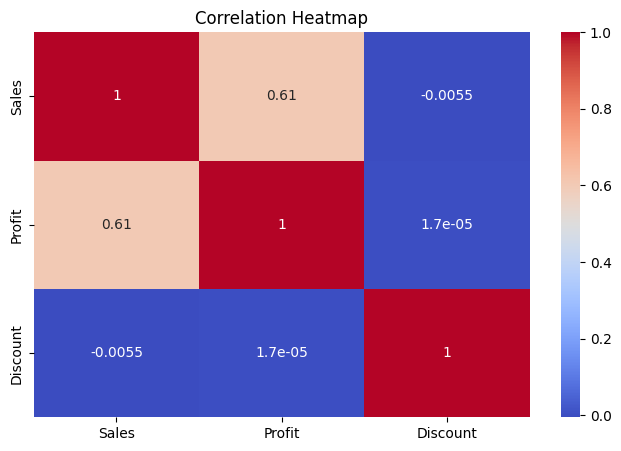

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['Sales','Profit','Discount']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Interpretation

The correlation heatmap examines the relationships between Sales, Profit, and Discount. A positive correlation indicates that two variables tend to increase together, while a negative correlation suggests an inverse relationship. Understanding these relationships provides valuable insights into how pricing and discount strategies influence profitability and sales performance.

### Business Insight

Analyzing correlations enables management to optimize discount policies and pricing strategies while maintaining healthy profit margins and revenue growth.


## Machine Learning - Sales Prediction

In [ ]:
data = df.copy()
data = data.drop(columns=['Order Date'])

for col in data.select_dtypes(include=['number']).columns:
    data[col] = data[col].fillna(data[col].median())

for col in data.select_dtypes(include=['object']).columns:
    data[col] = data[col].fillna(data[col].mode()[0])

cat_cols = ['Category','Sub Category','City','Region','State','Month']
for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

features = ['Category','Sub Category','City','Region','Discount',
            'Profit','State','month_no','Month','year']

X = data[features]
y = data['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print('Linear Regression R2 Score:', r2_score(y_test, pred_lr))
print('MSE:', mean_squared_error(y_test, pred_lr))

Linear Regression R2 Score: 0.3548404660255523
MSE: 212784.32822558706


### Interpretation

The Linear Regression model achieved an R² score of 0.3548, indicating that approximately 35.48% of the variation in sales can be explained by the selected features. While the model demonstrates some predictive capability, a substantial portion of sales variation remains unexplained, suggesting that additional factors may influence customer purchasing behavior.

### Business Insight

The results indicate that variables such as category, city, profit, discount, and seasonal factors contribute to sales performance. However, incorporating additional business features could improve prediction accuracy.


## Random Forest

In [ ]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print('Random Forest R2 Score:', r2_score(y_test, pred_rf))
print('MSE:', mean_squared_error(y_test, pred_rf))

Random Forest R2 Score: 0.32708851449106957
MSE: 221937.3827078414


### Interpretation

The Random Forest model achieved an R² score of 0.3271, explaining approximately 32.71% of the variance in sales. Although Random Forest is capable of capturing complex nonlinear relationships, it performed slightly worse than Linear Regression on this dataset. This suggests that the available features may not contain strong nonlinear patterns that significantly improve predictive performance.

### Business Insight

Since Linear Regression outperformed Random Forest in this analysis, simpler predictive models may be more appropriate for the current dataset. Future improvements could include additional customer, product, and promotional variables to enhance forecasting accuracy.


# Conclusion

This project analyzed the Supermart Grocery Sales dataset to understand customer purchasing patterns, sales performance, and business trends. Exploratory Data Analysis identified the highest-performing product categories, peak sales periods, and top revenue-generating cities. Correlation analysis provided insights into the relationships between sales, profit, and discount strategies.

Two machine learning models were developed to predict sales performance. Linear Regression achieved the highest R² score of 0.3548, outperforming Random Forest with an R² score of 0.3271. The results demonstrate that sales can be partially predicted using available business features, although additional variables may further improve model performance.

Overall, the project provides valuable insights that can support inventory management, marketing decisions, pricing strategies, and future business growth initiatives.
